# L10 : Markov Chain

The weather tomorrow depends on the weather today.
$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$
$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$
$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$
$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$
- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at
$$p({\rm clear}) = 0.83,$$
and 
$$p({\rm cloudy}) = 0.17.$$

#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.  
- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.
- Use a summary statistics to determine the most likely value and an error on our estimate.

In [8]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import astropy
import astroML.stats
import scipy.stats as stats

In [20]:
N = 10000
# 1 = clear 
# 0 = cloudy
weather = [0] # initial state

for i in range(1,N):
    if weather[i-1] == 1:
        weather.append(np.random.choice(np.array([0, 1]), p=np.array([0.1, 0.9])))

    if weather[i-1] == 0:
        weather.append(np.random.choice(np.array([0, 1]), p=np.array([0.5, 0.5])))

weather = np.array(weather)
days = np.arange(1, N + 1)
cumulative_clear = np.cumsum(weather)/days

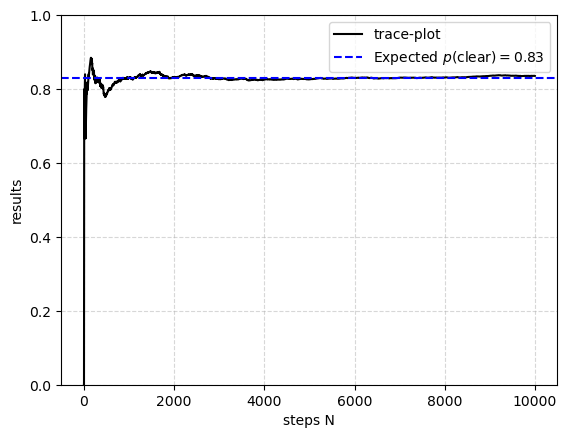

In [21]:
plt.plot(cumulative_clear, color='black', label='trace-plot')
plt.axhline(0.83, linestyle='--', color='blue', linewidth=1.5, label='Expected $p(\mathrm{clear}) = 0.83$')
plt.xlabel(r"steps N")
plt.ylabel("results")
plt.legend()
plt.ylim(0,1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

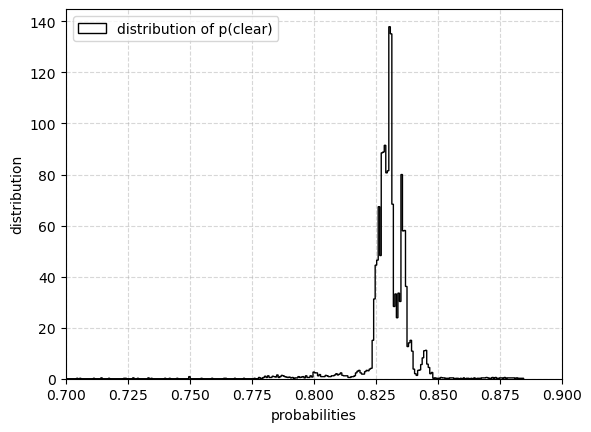

In [24]:
plt.hist(cumulative_clear, bins='fd', histtype="step", color='black', density=True, label='distribution of p(clear)');
plt.xlabel(r"probabilities")
plt.ylabel("distribution")
plt.xlim(0.7,0.9)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [32]:
print('median =', np.median(cumulative_clear))
print('sigmaG =', astroML.stats.sigmaG(cumulative_clear))

median = 0.8304226379062281
sigmaG = 0.004883175753948375


median = 0.8305149906389158
sigmaG = 0.004706033459275018


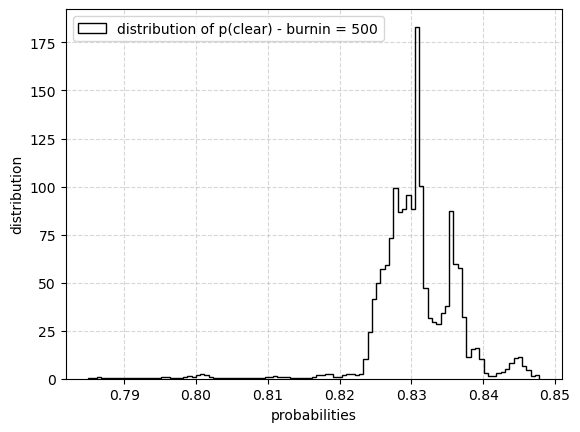

In [33]:
burnin = 500
cumulative_burnin = cumulative_clear[burnin:]

print('median =', np.median(cumulative_burnin))
print('sigmaG =', astroML.stats.sigmaG(cumulative_burnin))

plt.hist(cumulative_burnin, bins='fd', histtype="step", color='black', density=True, label='distribution of p(clear) - burnin = 500');
plt.xlabel(r"probabilities")
plt.ylabel("distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

median = 0.8306726491814432
sigmaG = 0.004823318334038286


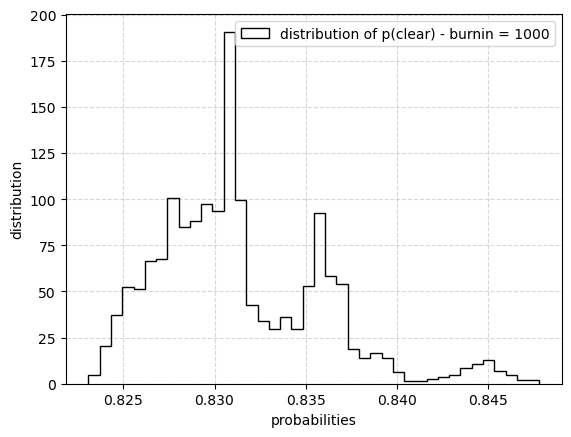

In [34]:
burnin = 1000
cumulative_burnin = cumulative_clear[burnin:]

print('median =', np.median(cumulative_burnin))
print('sigmaG =', astroML.stats.sigmaG(cumulative_burnin))

plt.hist(cumulative_burnin, bins='fd', histtype="step", color='black', density=True, label='distribution of p(clear) - burnin = 1000');
plt.xlabel(r"probabilities")
plt.ylabel("distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

median = 0.8304220669504588
sigmaG = 0.004773421237771116


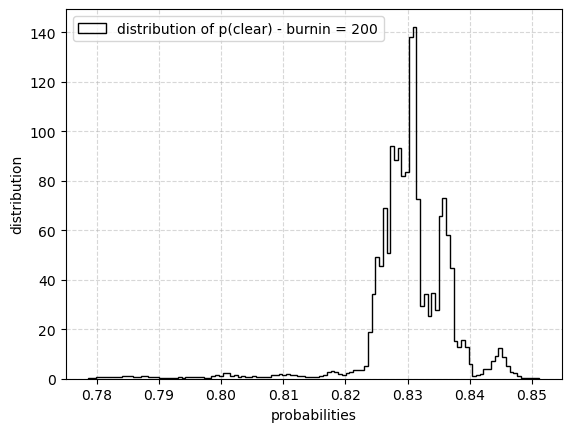

In [35]:
burnin = 200
cumulative_burnin = cumulative_clear[burnin:]

print('median =', np.median(cumulative_burnin))
print('sigmaG =', astroML.stats.sigmaG(cumulative_burnin))
plt.hist(cumulative_burnin, bins='fd', histtype="step", color='black', density=True, label='distribution of p(clear) - burnin = 200');
plt.xlabel(r"probabilities")
plt.ylabel("distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()